In [3]:
%load_ext IPython.extensions.autoreload
%autoreload 2
from latham.simulation import *
from latham.params import *
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import gzip

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


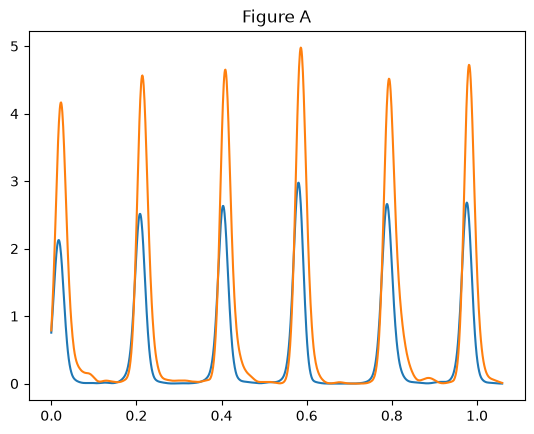

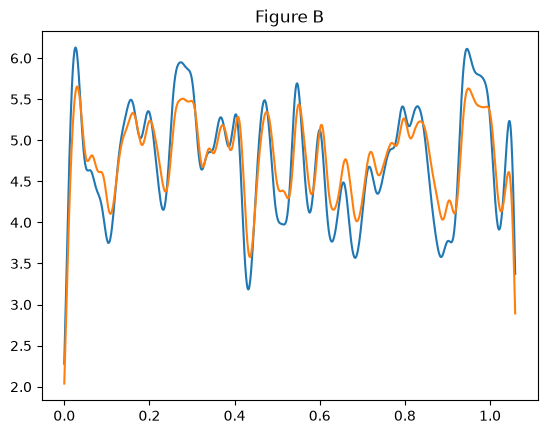

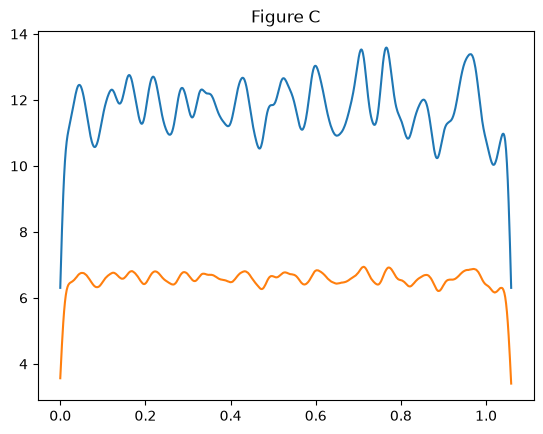

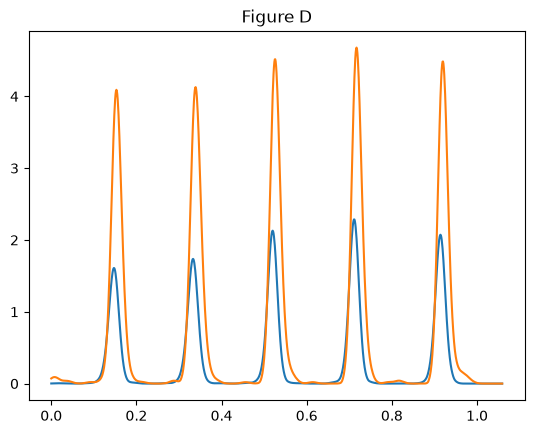

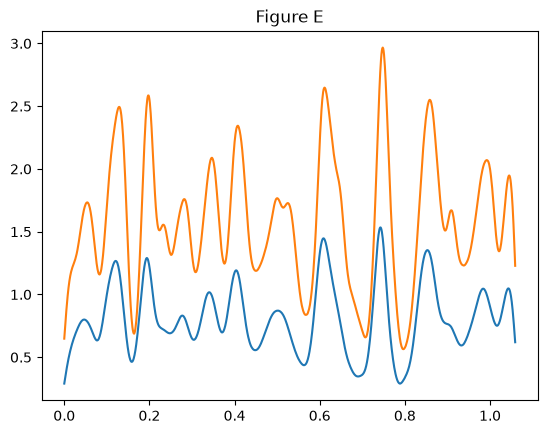

In [29]:
#params = {"A": network_A(5, 1.0, 0.8, 0.01), 
#          "B": network_A(5, 1.0, 1.0, 0.01), 
#          "C": network_A(5, 1.0, 1.2, 0.01), 
#          "D": network_A(5, 1.2, 0.8, 0.01), 
#          "E": network_A(5, 1.2, 1.0, 0.01), 
#          "F": network_A(5, 1.2, 1.2, 0.01)}
params = {"A": network_A(5, 1.0, 0.8, 0.01), 
          "B": network_A(5, 1.0, 1.0, 0.01), 
          "C": network_A(5, 1.0, 1.2, 0.01), 
          "D": network_A(5, 1.2, 0.8, 0.01), 
          "E": network_A(5, 1.2, 1.0, 0.01)}

def gaus(x, width):
    return 1 / width / np.sqrt(2 * np.pi) * np.exp(-1 / 2 * (x / width)**2)
window = gaus(np.arange(-30,30), 10)
for fig in params:
    res = None
    pkl_path = f"pkls/fig9/{fig}.pkl.gzip"
    
    #res = run_sim(*params[fig])
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)

    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    t, spikes, _ = res
    N_I = int(0.2 * 10000)
    inhib_rates = np.convolve(window, spikes[70000:71060,:N_I].sum(axis=1)) / N_I * 1000 # / 10000 * 1000
    excit_rates = np.convolve(window, spikes[70000:71060,N_I:].sum(axis=1)) / (10000 - N_I) * 1000 # / 10000 * 1000
    plt.title(f"Figure {fig}")
    plt.plot((t[70000:71060] - 70000) / 1000, excit_rates[30:-29])
    plt.plot((t[70000:71060] - 70000) / 1000, inhib_rates[30:-29])
    plt.show()

[0.         0.         0.         ... 0.16916849 0.16921018 0.16930683]


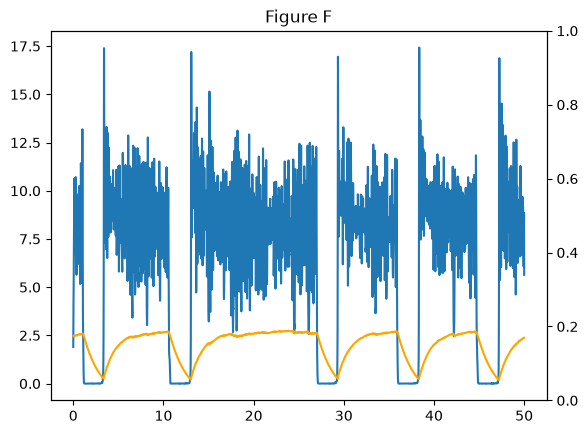

In [14]:
params = network_A(5, 1.2, 1.2, 0.01)

def gaus(x, width):
    return 1 / width / np.sqrt(2 * np.pi) * np.exp(-1 / 2 * (x / width)**2)
window = gaus(np.arange(-30,30), 10)
res = None
pkl_path = f"pkls/fig9/F.pkl.gzip"
    
#res = run_sim(*params, trace_g_K_Ca=ExcitatoryAverageTraceType())
#with gzip.open(pkl_path, "wb") as f:
#    pkl.dump(res, f)

with gzip.open(pkl_path, "rb") as f:
    res = pkl.load(f)

t, spikes, _, g_K_Ca_trace = res

fig, ax1 = plt.subplots()

N_I = int(0.2 * 10000)
excit_rates = np.convolve(window, spikes[50000:,N_I:].sum(axis=1)) / (10000 - N_I) * 1000 # / 10000 * 1000
plt.title("Figure F")
ax1.plot((t[50000:] - 50000) / 1000, excit_rates[30:-29])
ax2 = ax1.twinx()
ax2.set_ylim(0,1)
ax2.plot((t[50000:] - 50000) / 1000, g_K_Ca_trace[50000:], color="orange")
print(g_K_Ca_trace)
plt.show()